# Notebook 13 (V4_3) - Approximation Error in Terminal Tails

This notebook implements `AI_gen_prompts/Approximation_error_in_tails_analysis.md` for the two-country production economy, using the large-bubble `12_v9` calibration:

| object | value |
|---|---:|
| `gamma` | 0.25 |
| `pi_persist` | 0.80 |
| `xi_u` | 2.00 |
| `nu_u` | 1.50 |
| seed `nu_b`, `xi_W` | 0.50 |
| `common_world_growth` | true |
| `branch_iters` | 100 |

Two checks are run:

1. Horizon/buffer invariance around the certified `12_v9` baseline (`T_report = 45`, `n_buffer = 5`).
2. Terminal-rule sensitivity under four artificial successor rules: flat, local log-linear, asymptotic HKT-rate, and tail regression.

The default grid is intentionally smaller than the original prompt grid but still replication-grade. For a quick syntax/execution check, set `RUN_MODE = :smoke` in the first code cell, or run with `TAIL_ANALYSIS_MODE=smoke`.

In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)

include(joinpath(PROJECT_DIR, "Two_country_production", "TwoCountryProductionOLG.jl"))

using Printf, Statistics, Markdown
using Plots, LaTeXStrings
using Plots.PlotMeasures

gr()
default(size=(940, 560), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

const OUTDIR = joinpath(PROJECT_DIR, "Two_country_production", "outputs_v43",
                        "approximation_error_in_tails")
isdir(OUTDIR) || mkpath(OUTDIR)

RUN_MODE = Symbol(get(ENV, "TAIL_ANALYSIS_MODE", "replication"))
@assert RUN_MODE in (:replication, :smoke) "RUN_MODE must be :replication or :smoke"

println("Project directory: ", PROJECT_DIR)
println("Output directory:  ", OUTDIR)
println("Run mode:          ", RUN_MODE)

  Activating 

Project directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:  /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails
Run mode:          replication


## 0. Calibration and Grid

Replication mode uses the agreed smaller grid:

- Horizon/buffer grid: `T_report in {45, 60}`, `n_buffer in {0, 5, 20}`.
- Baseline reference: `T_report = 45`, `n_buffer = 5`, matching the certified `12_v9` common-growth run.
- Comparison windows: `T0 in {20, 30, 40}`.
- Terminal-rule sensitivity: `T_report = 45`, `n_buffer in {0, 5, 20}`.

Smoke mode keeps the same economic calibration but uses tiny horizons so the notebook can be checked quickly.

In [2]:
const RESID_TOL = 1e-5

function tail_combo_params(; T_max::Int, n_buffer::Int)
    return ProductionParams(T_max=T_max,
        γ=0.25,
        π_persist=0.80,
        ξ_u=2.0,
        ν_u=1.5,
        ν_b=0.5,
        ξ_W=0.5,
        common_world_growth=true,
        branch_iters=100,
        n_buffer=n_buffer,
        do_global_polish=false)
end

if RUN_MODE == :smoke
    BASELINE_SPEC = (T_report=5, n_buffer=2)
    HORIZON_T_GRID = [5, 6]
    BUFFER_GRID = [0, 2]
    T0_GRID = [2, 4]
    TERMINAL_T_REPORT = 5
    TERMINAL_BUFFER_GRID = [0, 2]
    TAIL_REGRESSION_K_DEFAULT = 4
else
    BASELINE_SPEC = (T_report=45, n_buffer=5)
    HORIZON_T_GRID = [45, 60]
    BUFFER_GRID = [0, 5, 20]
    T0_GRID = [20, 30, 40]
    TERMINAL_T_REPORT = 45
    TERMINAL_BUFFER_GRID = [0, 5, 20]
    TAIL_REGRESSION_K_DEFAULT = 8
end

TERMINAL_RULES = [:flat, :local_loglinear, :asymptotic_hkt, :tail_regression]

println("Baseline spec: ", BASELINE_SPEC)
println("Horizon grid:  T_report=", HORIZON_T_GRID, ", n_buffer=", BUFFER_GRID)
println("T0 windows:    ", T0_GRID)
println("Terminal grid: T_report=", TERMINAL_T_REPORT, ", n_buffer=", TERMINAL_BUFFER_GRID)

Baseline spec: (T_report = 45, n_buffer = 5)
Horizon grid:  T_report=[45, 60], n_buffer=[0, 5, 20]
T0 windows:    [20, 30, 40]
Terminal grid: T_report=45, n_buffer=[0, 5, 20]


## 1. Notebook-Local Terminal Closure Dispatcher

The production module is left untouched. After `include(...)`, this cell replaces the existing `_extrapolate_terminal!` method with a dispatcher controlled by `TAIL_TERMINAL_RULE[]`.

The current model rule is `:local_loglinear`, i.e. `phi_{T+1} = phi_T^2 / phi_{T-1}` for both country labour-allocation coordinates. The HKT asymptotic-rate rule is applied to the U.S. unbalanced branch; the RoW coordinate is carried by the local log-linear rule because the HKT decay bound is a U.S. unbalanced-branch condition.

In [3]:
const TAIL_TERMINAL_RULE = Ref(:local_loglinear)
const TAIL_TERMINAL_PARAMS = Ref{Any}(nothing)
const TAIL_REGRESSION_K = Ref(TAIL_REGRESSION_K_DEFAULT)

phi_clamp(x) = clamp(x, 1e-8, 1 - 1e-8)

function local_loglinear_phi(pol::Matrix{Float64}, i::Int, T::Int)
    if T >= 2
        a, b = pol[i, T-1], pol[i, T]
        if isfinite(a) && isfinite(b) && a > 1e-12 && b > 1e-12
            return phi_clamp(b * b / a)
        end
    end
    return phi_clamp(pol[i, T])
end

function tail_regression_phi(pol::Matrix{Float64}, i::Int, T::Int; k::Int=8)
    lo = max(1, T - k + 1)
    idx = [t for t in lo:T if isfinite(pol[i, t]) && pol[i, t] > 1e-12]
    length(idx) < 3 && return local_loglinear_phi(pol, i, T)

    x = Float64.(idx)
    y = log.([pol[i, t] for t in idx])
    xbar = mean(x); ybar = mean(y)
    sxx = sum(abs2, x .- xbar)
    sxx <= 0 && return local_loglinear_phi(pol, i, T)

    slope = sum((x .- xbar) .* (y .- ybar)) / sxx
    intercept = ybar - slope * xbar
    return phi_clamp(exp(intercept + slope * (T + 1)))
end

function asymptotic_hkt_phi_us(pol::Matrix{Float64}, T::Int)
    p = TAIL_TERMINAL_PARAMS[]
    p === nothing && return local_loglinear_phi(pol, 1, T)

    phi_T = phi_clamp(pol[1, T])
    psi_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
    asymptotic_rate = G_N_US(p, phi_T)^(-psi_US / p.ρ_US)
    if isfinite(asymptotic_rate) && asymptotic_rate > 0
        return phi_clamp(phi_T * asymptotic_rate)
    end
    return local_loglinear_phi(pol, 1, T)
end

# Notebook-local replacement of the model's terminal closure.
function _extrapolate_terminal!(pol::Matrix{Float64}, T::Int)
    pol[:, T+1] .= pol[:, T]
    rule = TAIL_TERMINAL_RULE[]

    if rule == :flat
        return pol
    elseif rule == :local_loglinear
        pol[1, T+1] = local_loglinear_phi(pol, 1, T)
        pol[2, T+1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :asymptotic_hkt
        pol[1, T+1] = asymptotic_hkt_phi_us(pol, T)
        pol[2, T+1] = local_loglinear_phi(pol, 2, T)
    elseif rule == :tail_regression
        pol[1, T+1] = tail_regression_phi(pol, 1, T; k=TAIL_REGRESSION_K[])
        pol[2, T+1] = tail_regression_phi(pol, 2, T; k=TAIL_REGRESSION_K[])
    else
        error("Unknown terminal rule: $rule")
    end
    return pol
end

function set_terminal_rule!(rule::Symbol, p::ProductionParams)
    @assert rule in TERMINAL_RULES "unknown terminal rule"
    TAIL_TERMINAL_RULE[] = rule
    TAIL_TERMINAL_PARAMS[] = p
    return rule
end

println("Installed notebook-local terminal closure dispatcher.")

Installed notebook-local terminal closure dispatcher.


## 2. Helpers

Each solve returns the equilibrium path, the fundamental-value recursion, a compact certification row, and any caught error. Results are cached by `(T_report, n_buffer, terminal_rule)` so the local-loglinear runs used in both sections are not repeated.

In [4]:
path_vector(result, field::Symbol) = [getfield(s, field) for s in result.u_path]

function positive_for_log(x; floor=1e-20)
    return max.(Float64.(x), floor)
end

function pretty(x)
    x === missing && return ""
    x isa Bool && return string(x)
    x isa Integer && return string(x)
    if x isa AbstractFloat
        if !isfinite(x)
            return string(x)
        elseif abs(x) >= 1000 || (abs(x) > 0 && abs(x) < 1e-3)
            return @sprintf("%.3e", x)
        else
            return @sprintf("%.6f", x)
        end
    end
    return string(x)
end

function html_escape(x)
    s = string(x)
    s = replace(s, "&" => "&amp;")
    s = replace(s, "<" => "&lt;")
    s = replace(s, ">" => "&gt;")
    s = replace(s, "_" => "\\_")
    return s
end

function markdown_table(rows, cols; maxrows=length(rows))
    isempty(rows) && return Markdown.parse("_No rows._")
    io = IOBuffer()
    println(io, "| ", join([html_escape(c) for c in cols], " | "), " |")
    println(io, "| ", join(fill("---", length(cols)), " | "), " |")
    for r in rows[1:min(maxrows, length(rows))]
        println(io, "| ", join([html_escape(pretty(getproperty(r, Symbol(c)))) for c in cols], " | "), " |")
    end
    Markdown.parse(String(take!(io)))
end

function csv_escape(x)
    x === missing && return ""
    s = string(x)
    if occursin(',', s) || occursin('"', s) || occursin('\n', s)
        return "\"" * replace(s, "\"" => "\"\"") * "\""
    end
    return s
end

function write_csv(filename, rows, cols)
    open(filename, "w") do io
        println(io, join(cols, ","))
        for r in rows
            println(io, join([csv_escape(getproperty(r, Symbol(c))) for c in cols], ","))
        end
    end
    return filename
end

const RESULT_CACHE = Dict{Tuple{Int,Int,Symbol},Any}()

function run_tail_case(T_report::Int, n_buffer::Int, rule::Symbol; verbose::Bool=false)
    key = (T_report, n_buffer, rule)
    haskey(RESULT_CACHE, key) && return RESULT_CACHE[key]

    p = tail_combo_params(T_max=T_report, n_buffer=n_buffer)
    set_terminal_rule!(rule, p)
    @printf("Solving T=%d, buffer=%d, terminal=%s\n", T_report, n_buffer, String(rule))

    t0 = time()
    try
        result = run_production_simulation(p; verbose=verbose)
        fv = fundamental_value_path(result)
        elapsed = time() - t0
        q = path_vector(result, :q_US)
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="ok",
            branch_converged=result.branch_converged,
            max_u_residual=result.max_u_residual,
            max_bgp_residual=result.max_bgp_residual,
            psi_ok=result.diagnostics.psi_ok,
            psi_min=result.diagnostics.psi_min,
            equity_weights_ok=result.diagnostics.equity_weights_ok,
            equity_weight_min=result.diagnostics.equity_weight_min,
            nu_b_effective=result.params.ν_b,
            q_growth=q[end] / q[1],
            bubble_share_final=fv.bubble_share[end],
            bubble_share_max=maximum(fv.bubble_share),
            error="")
        out = (; status=:ok, result, fv, summary)
        RESULT_CACHE[key] = out
        return out
    catch err
        elapsed = time() - t0
        summary = (;
            T_report=T_report,
            n_buffer=n_buffer,
            terminal_rule=String(rule),
            elapsed_sec=elapsed,
            status="error",
            branch_converged=missing,
            max_u_residual=missing,
            max_bgp_residual=missing,
            psi_ok=missing,
            psi_min=missing,
            equity_weights_ok=missing,
            equity_weight_min=missing,
            nu_b_effective=missing,
            q_growth=missing,
            bubble_share_final=missing,
            bubble_share_max=missing,
            error=sprint(showerror, err))
        out = (; status=:error, result=nothing, fv=nothing, summary)
        RESULT_CACHE[key] = out
        @warn "Solve failed" T_report n_buffer rule err
        return out
    end
end

function comparison_metrics(case, ref, T0::Int)
    if case.status != :ok || ref.status != :ok
        return (max_log_q_error=missing,
                max_log_dividend_yield_error=missing,
                max_phi_error=missing,
                max_bubble_share_error=missing)
    end

    T = min(length(case.result.u_path), length(ref.result.u_path))
    if T0 > T
        return (max_log_q_error=missing,
                max_log_dividend_yield_error=missing,
                max_phi_error=missing,
                max_bubble_share_error=missing)
    end

    idx = 1:T0
    q = path_vector(case.result, :q_US)[idx]
    d = path_vector(case.result, :d_US)[idx]
    phi = path_vector(case.result, :φ_US)[idx]
    bshare = case.fv.bubble_share[idx]

    q_ref = path_vector(ref.result, :q_US)[idx]
    d_ref = path_vector(ref.result, :d_US)[idx]
    phi_ref = path_vector(ref.result, :φ_US)[idx]
    bshare_ref = ref.fv.bubble_share[idx]

    return (;
        max_log_q_error=maximum(abs.(log.(q) .- log.(q_ref))),
        max_log_dividend_yield_error=maximum(abs.(log.(d ./ q) .- log.(d_ref ./ q_ref))),
        max_phi_error=maximum(abs.(phi .- phi_ref)),
        max_bubble_share_error=maximum(abs.(bshare .- bshare_ref)))
end

comparison_metrics (generic function with 1 method)

## 3. Horizon and Buffer Invariance

Each candidate is compared with the `12_v9` baseline-centered reference using the current local log-linear terminal rule. The reported metrics match the prompt:

$$
\max_{t \le T_0}\left|\log q_t-\log q_t^{ref}\right|,
\quad
\max_{t \le T_0}\left|\log(d_t/q_t)-\log(d_t/q_t)^{ref}\right|,
$$
$$
\max_{t \le T_0}\left|\phi_t-\phi_t^{ref}\right|,
\quad
\max_{t \le T_0}\left|B_t/Q_t-(B_t/Q_t)^{ref}\right|.
$$

In [5]:
baseline_case = run_tail_case(BASELINE_SPEC.T_report, BASELINE_SPEC.n_buffer, :local_loglinear)

horizon_cases = Any[]
for T_report in HORIZON_T_GRID, n_buffer in BUFFER_GRID
    push!(horizon_cases, run_tail_case(T_report, n_buffer, :local_loglinear))
end

horizon_case_summary = [c.summary for c in horizon_cases]

horizon_rows = NamedTuple[]
for c in horizon_cases
    for T0 in T0_GRID
        m = comparison_metrics(c, baseline_case, T0)
        push!(horizon_rows, merge((;
            T_report=c.summary.T_report,
            n_buffer=c.summary.n_buffer,
            terminal_rule=c.summary.terminal_rule,
            baseline_T_report=BASELINE_SPEC.T_report,
            baseline_n_buffer=BASELINE_SPEC.n_buffer,
            T0=T0,
            status=c.summary.status,
            max_u_residual=c.summary.max_u_residual,
            max_bgp_residual=c.summary.max_bgp_residual), m))
    end
end

markdown_table(horizon_rows,
    ["T_report", "n_buffer", "T0", "status", "max_u_residual",
     "max_log_q_error", "max_log_dividend_yield_error", "max_phi_error",
     "max_bubble_share_error"]; maxrows=length(horizon_rows))

Solving T=45, buffer=5, terminal=local_loglinear
Solving T=45, buffer=0, terminal=local_loglinear
Solving T=45, buffer=20, terminal=local_loglinear
Solving T=60, buffer=0, terminal=local_loglinear
Solving T=60, buffer=5, terminal=local_loglinear
Solving T=60, buffer=20, terminal=local_loglinear


| T_report | n_buffer |  T0 | status | max_u_residual | max_log_q_error | max_log_dividend_yield_error | max_phi_error | max_bubble_share_error |
| --------:| --------:| ---:| ------:| --------------:| ---------------:| ----------------------------:| -------------:| ----------------------:|
|       45 |        0 |  20 |     ok |      1.472e-04 |       4.159e-06 |                    2.229e-06 |     1.258e-06 |               0.011973 |
|       45 |        0 |  30 |     ok |      1.472e-04 |       3.295e-05 |                    1.738e-05 |     7.847e-06 |               0.059849 |
|       45 |        0 |  40 |     ok |      1.472e-04 |       1.287e-04 |                    6.700e-05 |     2.207e-05 |               0.162076 |
|       45 |        5 |  20 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        5 |  30 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        5 |  40 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |       20 |  20 |     ok |      2.810e-06 |       7.402e-05 |                    3.968e-05 |     2.240e-05 |               0.016138 |
|       45 |       20 |  30 |     ok |      2.810e-06 |       5.981e-04 |                    3.156e-04 |     1.424e-04 |               0.080694 |
|       45 |       20 |  40 |     ok |      2.810e-06 |        0.002357 |                     0.001227 |     4.038e-04 |               0.218749 |
|       60 |        0 |  20 |     ok |       0.001168 |       5.976e-05 |                    3.204e-05 |     1.809e-05 |               0.012625 |
|       60 |        0 |  30 |     ok |       0.001168 |       4.829e-04 |                    2.548e-04 |     1.150e-04 |               0.063134 |
|       60 |        0 |  40 |     ok |       0.001168 |        0.001904 |                    9.911e-04 |     3.263e-04 |               0.171185 |
|       60 |        5 |  20 |     ok |      6.569e-06 |       7.402e-05 |                    3.968e-05 |     2.240e-05 |               0.016138 |
|       60 |        5 |  30 |     ok |      6.569e-06 |       5.981e-04 |                    3.156e-04 |     1.424e-04 |               0.080694 |
|       60 |        5 |  40 |     ok |      6.569e-06 |        0.002357 |                     0.001227 |     4.038e-04 |               0.218749 |
|       60 |       20 |  20 |     ok |      1.267e-09 |       5.387e-05 |                    2.888e-05 |     1.630e-05 |               0.030251 |
|       60 |       20 |  30 |     ok |      1.267e-09 |       4.339e-04 |                    2.289e-04 |     1.034e-04 |               0.151190 |
|       60 |       20 |  40 |     ok |      1.267e-09 |        0.001713 |                    8.919e-04 |     2.939e-04 |               0.409270 |


In [6]:
summary_cols = ["T_report", "n_buffer", "terminal_rule", "elapsed_sec", "status",
                "branch_converged", "max_u_residual", "max_bgp_residual", "psi_ok",
                "psi_min", "equity_weights_ok", "equity_weight_min", "nu_b_effective",
                "q_growth", "bubble_share_final", "bubble_share_max", "error"]
metric_cols = ["T_report", "n_buffer", "terminal_rule", "baseline_T_report",
               "baseline_n_buffer", "T0", "status", "max_u_residual",
               "max_bgp_residual", "max_log_q_error",
               "max_log_dividend_yield_error", "max_phi_error",
               "max_bubble_share_error"]

write_csv(joinpath(OUTDIR, "horizon_buffer_case_summary.csv"), horizon_case_summary, summary_cols)
write_csv(joinpath(OUTDIR, "horizon_buffer_invariance.csv"), horizon_rows, metric_cols)
println("Saved horizon/buffer tables to ", OUTDIR)

Saved horizon/buffer tables to /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails


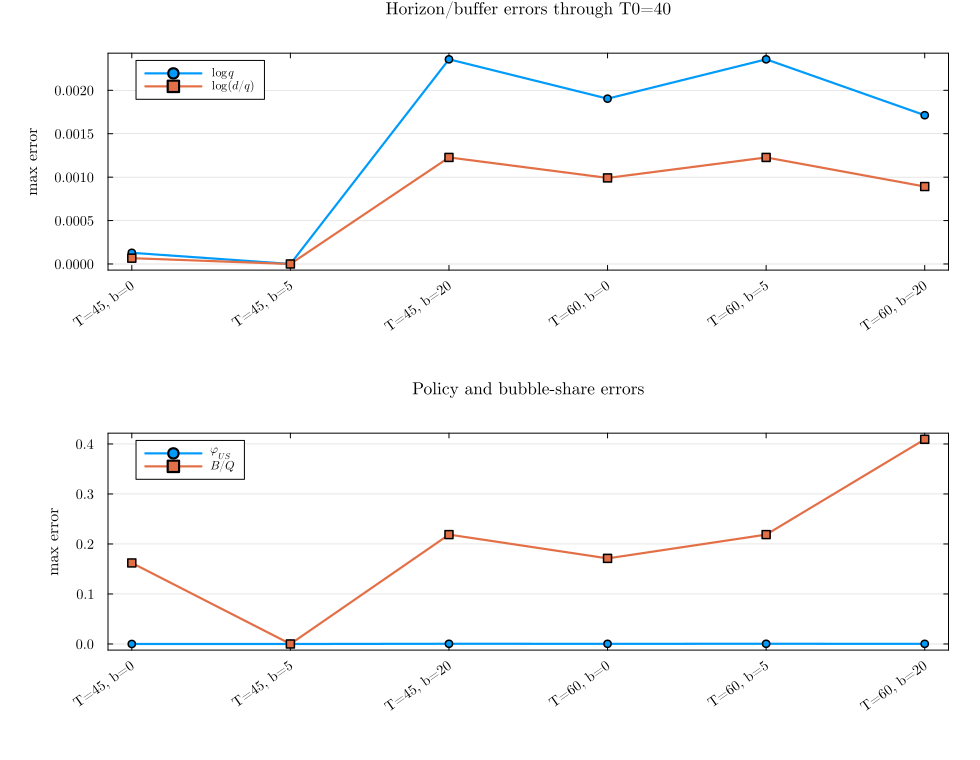

In [7]:
plot_T0 = maximum(T0_GRID)
hrows_plot = filter(r -> r.T0 == plot_T0 && r.status == "ok" && r.max_log_q_error !== missing, horizon_rows)
labels = ["T=$(r.T_report), b=$(r.n_buffer)" for r in hrows_plot]
x = 1:length(hrows_plot)

p1 = plot(x, [r.max_log_q_error for r in hrows_plot], marker=:circle, lw=2.2,
          xticks=(x, labels), xrotation=35, ylabel="max error", title="Horizon/buffer errors through T0=$plot_T0",
          label=L"\log q")
plot!(p1, x, [r.max_log_dividend_yield_error for r in hrows_plot], marker=:square, lw=2.2,
      label=L"\log(d/q)")

p2 = plot(x, [r.max_phi_error for r in hrows_plot], marker=:circle, lw=2.2,
          xticks=(x, labels), xrotation=35, ylabel="max error", title="Policy and bubble-share errors",
          label=L"\varphi_{US}")
plot!(p2, x, [r.max_bubble_share_error for r in hrows_plot], marker=:square, lw=2.2,
      label=L"B/Q")

fig_horizon = plot(p1, p2, layout=(2,1), size=(980, 760), bottom_margin=12mm)
savefig(fig_horizon, joinpath(OUTDIR, "horizon_buffer_invariance_errors.png"))
fig_horizon

### 3.1 Bubble-Share Path Diagnostics

The aggregate bubble share is computed as

$$
B_t/Q_t = 1 - v_t/q_t,
$$

where $v_t$ is a backward fundamental-value recursion evaluated on the extended scratch-buffer path. This makes `B/Q` more tail-sensitive than the equilibrium policy objects themselves: changing `T_report` or `n_buffer` changes where the no-bubble terminal closure is imposed for the fundamental-value recursion. The next cells plot the full `B/Q` paths and the pathwise errors against the `12_v9` baseline-centered reference.


Saved B/Q path table to /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails/horizon_buffer_bubble_share_paths.csv


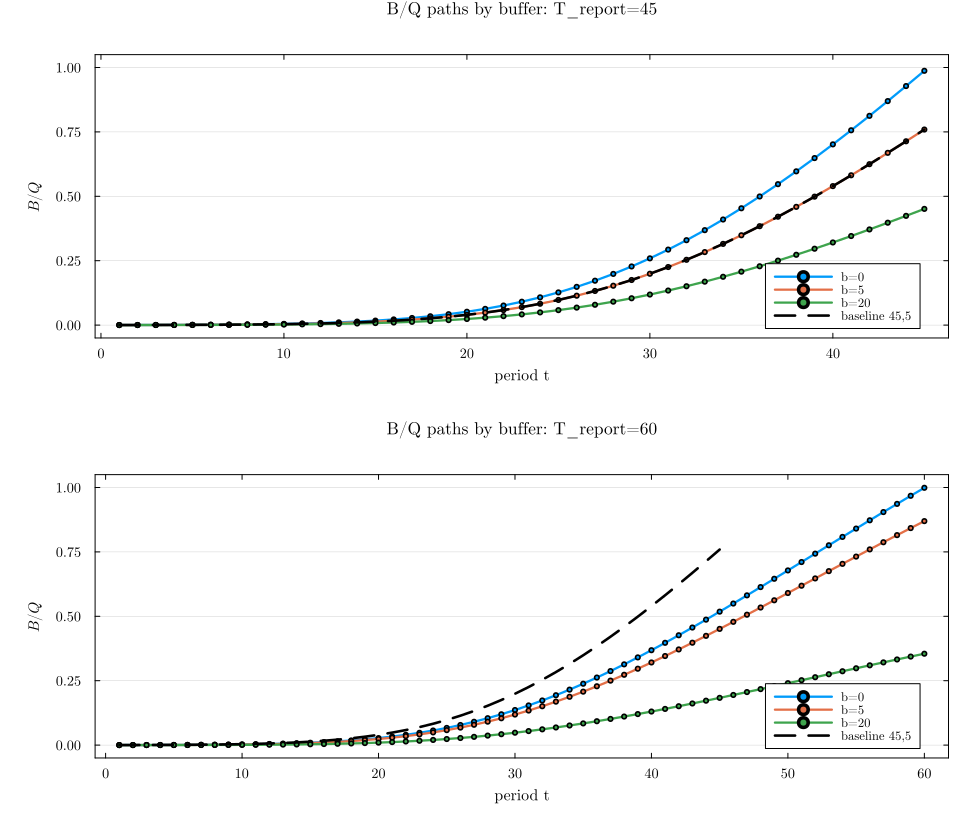

In [8]:
function case_label(c)
    return "T=$(c.summary.T_report), b=$(c.summary.n_buffer)"
end

function horizon_case_lookup(cases, T_report::Int, n_buffer::Int)
    idx = findfirst(c -> c.summary.T_report == T_report && c.summary.n_buffer == n_buffer, cases)
    idx === nothing && return nothing
    return cases[idx]
end

function maybe_ref_value(values, t::Int)
    t <= length(values) ? values[t] : missing
end

base_bq = baseline_case.status == :ok ? baseline_case.fv.bubble_share : Float64[]
base_q = baseline_case.status == :ok ? path_vector(baseline_case.result, :q_US) : Float64[]
base_phi = baseline_case.status == :ok ? path_vector(baseline_case.result, :φ_US) : Float64[]

horizon_path_rows = NamedTuple[]
for c in horizon_cases
    c.status == :ok || continue
    q = path_vector(c.result, :q_US)
    phi = path_vector(c.result, :φ_US)
    for t in 1:length(c.result.u_path)
        bq = c.fv.bubble_share[t]
        ref_bq = maybe_ref_value(base_bq, t)
        ref_q = maybe_ref_value(base_q, t)
        ref_phi = maybe_ref_value(base_phi, t)
        push!(horizon_path_rows, (;
            T_report=c.summary.T_report,
            n_buffer=c.summary.n_buffer,
            t=t,
            solved_terminal=length(c.result.u_path_extended),
            periods_to_terminal=length(c.result.u_path_extended) - t,
            q_US=q[t],
            v_US=c.fv.v[t],
            fundamental_share=c.fv.v[t] / q[t],
            bubble_share=bq,
            baseline_bubble_share=ref_bq,
            bubble_share_error=ref_bq === missing ? missing : bq - ref_bq,
            log_q_error=ref_q === missing ? missing : log(q[t]) - log(ref_q),
            phi_error=ref_phi === missing ? missing : phi[t] - ref_phi))
    end
end

path_cols = ["T_report", "n_buffer", "t", "solved_terminal", "periods_to_terminal",
             "q_US", "v_US", "fundamental_share", "bubble_share",
             "baseline_bubble_share", "bubble_share_error", "log_q_error", "phi_error"]
write_csv(joinpath(OUTDIR, "horizon_buffer_bubble_share_paths.csv"), horizon_path_rows, path_cols)
println("Saved B/Q path table to ", joinpath(OUTDIR, "horizon_buffer_bubble_share_paths.csv"))

panels = Any[]
for T_report in HORIZON_T_GRID
    panel = plot(title="B/Q paths by buffer: T_report=$T_report",
                 xlabel="period t", ylabel=L"B/Q", legend=:bottomright,
                 ylims=(-0.05, 1.05))
    for n_buffer in BUFFER_GRID
        c = horizon_case_lookup(horizon_cases, T_report, n_buffer)
        c === nothing && continue
        c.status == :ok || continue
        tt = 1:length(c.result.u_path)
        plot!(panel, tt, c.fv.bubble_share, lw=2.3, marker=:circle, ms=2.5,
              label="b=$n_buffer")
    end
    if baseline_case.status == :ok
        tt_base = 1:length(baseline_case.result.u_path)
        plot!(panel, tt_base, baseline_case.fv.bubble_share, lw=2.6, lc=:black,
              ls=:dash, label="baseline 45,5")
    end
    push!(panels, panel)
end

fig_bq_paths = plot(panels..., layout=(length(panels), 1), size=(980, 420 * length(panels)),
                    bottom_margin=8mm)
savefig(fig_bq_paths, joinpath(OUTDIR, "horizon_buffer_bubble_share_paths.png"))
fig_bq_paths


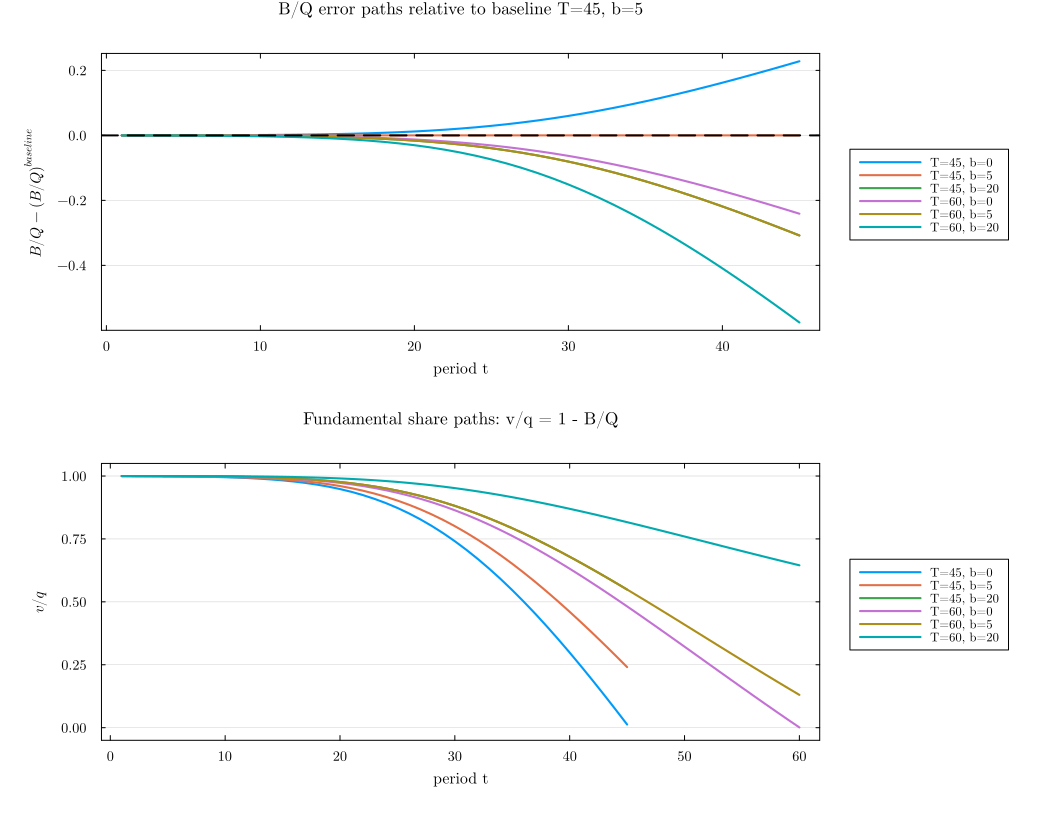

In [9]:
p_bq_err = plot(title="B/Q error paths relative to baseline T=45, b=5",
                xlabel="period t", ylabel=L"B/Q - (B/Q)^{baseline}", legend=:outerright)
p_fund = plot(title="Fundamental share paths: v/q = 1 - B/Q",
              xlabel="period t", ylabel=L"v/q", legend=:outerright,
              ylims=(-0.05, 1.05))

for c in horizon_cases
    c.status == :ok || continue
    label = case_label(c)
    tt = 1:min(length(c.result.u_path), length(base_bq))
    isempty(tt) && continue
    plot!(p_bq_err, tt, c.fv.bubble_share[tt] .- base_bq[tt], lw=2.1, label=label)
    plot!(p_fund, 1:length(c.result.u_path), 1 .- c.fv.bubble_share, lw=2.1, label=label)
end
hline!(p_bq_err, [0.0], lc=:black, ls=:dash, label="")

fig_bq_error_paths = plot(p_bq_err, p_fund, layout=(2,1), size=(1040, 820), bottom_margin=8mm)
savefig(fig_bq_error_paths, joinpath(OUTDIR, "horizon_buffer_bubble_share_error_paths.png"))
fig_bq_error_paths


In [10]:
function bubble_share_diagnostic_row(c, ref, T0::Int)
    if c.status != :ok || ref.status != :ok
        return (T_report=c.summary.T_report, n_buffer=c.summary.n_buffer, T0=T0,
                t_max=missing, max_abs_bubble_share_error=missing,
                bubble_share_at_t=missing, baseline_bubble_share_at_t=missing,
                fundamental_share_at_t=missing, baseline_fundamental_share_at_t=missing,
                abs_log_q_error_at_t=missing, abs_phi_error_at_t=missing,
                solved_terminal=missing, periods_to_terminal_at_t=missing,
                endpoint_bubble_share=missing, endpoint_fundamental_share=missing,
                max_u_residual=c.summary.max_u_residual)
    end

    T = min(T0, length(c.result.u_path), length(ref.result.u_path))
    if T <= 0
        return (T_report=c.summary.T_report, n_buffer=c.summary.n_buffer, T0=T0,
                t_max=missing, max_abs_bubble_share_error=missing,
                bubble_share_at_t=missing, baseline_bubble_share_at_t=missing,
                fundamental_share_at_t=missing, baseline_fundamental_share_at_t=missing,
                abs_log_q_error_at_t=missing, abs_phi_error_at_t=missing,
                solved_terminal=length(c.result.u_path_extended), periods_to_terminal_at_t=missing,
                endpoint_bubble_share=c.fv.bubble_share[end], endpoint_fundamental_share=1 - c.fv.bubble_share[end],
                max_u_residual=c.summary.max_u_residual)
    end

    err = c.fv.bubble_share[1:T] .- ref.fv.bubble_share[1:T]
    tstar = argmax(abs.(err))
    q = path_vector(c.result, :q_US)
    q_ref = path_vector(ref.result, :q_US)
    phi = path_vector(c.result, :φ_US)
    phi_ref = path_vector(ref.result, :φ_US)

    return (;
        T_report=c.summary.T_report,
        n_buffer=c.summary.n_buffer,
        T0=T0,
        t_max=tstar,
        max_abs_bubble_share_error=abs(err[tstar]),
        bubble_share_at_t=c.fv.bubble_share[tstar],
        baseline_bubble_share_at_t=ref.fv.bubble_share[tstar],
        fundamental_share_at_t=1 - c.fv.bubble_share[tstar],
        baseline_fundamental_share_at_t=1 - ref.fv.bubble_share[tstar],
        abs_log_q_error_at_t=abs(log(q[tstar]) - log(q_ref[tstar])),
        abs_phi_error_at_t=abs(phi[tstar] - phi_ref[tstar]),
        solved_terminal=length(c.result.u_path_extended),
        periods_to_terminal_at_t=length(c.result.u_path_extended) - tstar,
        endpoint_bubble_share=c.fv.bubble_share[end],
        endpoint_fundamental_share=1 - c.fv.bubble_share[end],
        max_u_residual=c.summary.max_u_residual)
end

bubble_diag_rows = [bubble_share_diagnostic_row(c, baseline_case, maximum(T0_GRID)) for c in horizon_cases]
bubble_diag_cols = ["T_report", "n_buffer", "T0", "t_max", "max_abs_bubble_share_error",
                    "bubble_share_at_t", "baseline_bubble_share_at_t",
                    "fundamental_share_at_t", "baseline_fundamental_share_at_t",
                    "abs_log_q_error_at_t", "abs_phi_error_at_t",
                    "solved_terminal", "periods_to_terminal_at_t",
                    "endpoint_bubble_share", "endpoint_fundamental_share", "max_u_residual"]
write_csv(joinpath(OUTDIR, "horizon_buffer_bubble_share_diagnostics.csv"), bubble_diag_rows, bubble_diag_cols)

markdown_table(bubble_diag_rows,
    ["T_report", "n_buffer", "t_max", "max_abs_bubble_share_error",
     "fundamental_share_at_t", "baseline_fundamental_share_at_t",
     "abs_log_q_error_at_t", "abs_phi_error_at_t",
     "periods_to_terminal_at_t", "endpoint_bubble_share", "max_u_residual"];
    maxrows=length(bubble_diag_rows))


| T_report | n_buffer | t_max | max_abs_bubble_share_error | fundamental_share_at_t | baseline_fundamental_share_at_t | abs_log_q_error_at_t | abs_phi_error_at_t | periods_to_terminal_at_t | endpoint_bubble_share | max_u_residual |
| --------:| --------:| -----:| --------------------------:| ----------------------:| -------------------------------:| --------------------:| ------------------:| ------------------------:| ---------------------:| --------------:|
|       45 |        0 |    40 |                   0.162076 |               0.298343 |                        0.460419 |            1.287e-04 |          2.207e-05 |                        5 |              0.987309 |      1.472e-04 |
|       45 |        5 |     1 |                   0.000000 |               0.999775 |                        0.999775 |             0.000000 |           0.000000 |                       49 |              0.759225 |      8.512e-06 |
|       45 |       20 |    40 |                   0.218749 |               0.679167 |                        0.460419 |             0.002357 |          4.038e-04 |                       25 |              0.451156 |      2.810e-06 |
|       60 |        0 |    40 |                   0.171185 |               0.631604 |                        0.460419 |             0.001904 |          3.263e-04 |                       20 |              0.998987 |       0.001168 |
|       60 |        5 |    40 |                   0.218749 |               0.679167 |                        0.460419 |             0.002357 |          4.038e-04 |                       25 |              0.869587 |      6.569e-06 |
|       60 |       20 |    40 |                   0.409270 |               0.869689 |                        0.460419 |             0.001713 |          2.939e-04 |                       40 |              0.354764 |      1.267e-09 |


**Interpretation.** If the diagnostics table shows large `B/Q` differences at the same dates where `abs_log_q_error_at_t` and `abs_phi_error_at_t` are tiny, the variation is coming from the fundamental-value tail, not from materially different equilibrium prices or policies. A shorter effective tail imposes the absorbing no-bubble closure closer to the reported window, lowers the recursively computed `v/q`, and therefore raises `B/Q = 1 - v/q`. Larger buffers generally give the recursion more continuation-branch cash-flow tail before the closure, so the fundamental share rises and the measured bubble share falls.

This is why `fig_horizon` can show tiny `q` and `phi` errors but large bubble-share errors: the first two are direct solved-path objects, while `B/Q` is a tail-sensitive valuation object built by a separate backward recursion. The right robustness check is therefore the B/Q path and `v/q` path above, not just the policy/path residuals.


## 4. Terminal-Rule Sensitivity

This section compares four terminal successor rules at the `12_v9` calibration. For each buffer, every rule is compared with the local log-linear rule at the same reported horizon and buffer. This isolates closure sensitivity from the mechanical effect of changing the buffer length.

Rules:

- `flat`: `phi_{T+1} = phi_T`, intentionally bad near the terminal date.
- `local_loglinear`: current model rule, `phi_{T+1} = phi_T^2 / phi_{T-1}`.
- `asymptotic_hkt`: U.S. HKT decay-rate rule, with RoW local-loglinear.
- `tail_regression`: log-linear regression over the last `k` solved periods.

In [11]:
terminal_cases = Any[]
for n_buffer in TERMINAL_BUFFER_GRID, rule in TERMINAL_RULES
    push!(terminal_cases, run_tail_case(TERMINAL_T_REPORT, n_buffer, rule))
end

terminal_case_summary = [c.summary for c in terminal_cases]

terminal_rows = NamedTuple[]
for n_buffer in TERMINAL_BUFFER_GRID
    ref = run_tail_case(TERMINAL_T_REPORT, n_buffer, :local_loglinear)
    for rule in TERMINAL_RULES
        c = run_tail_case(TERMINAL_T_REPORT, n_buffer, rule)
        for T0 in T0_GRID
            m = comparison_metrics(c, ref, T0)
            push!(terminal_rows, merge((;
                T_report=TERMINAL_T_REPORT,
                n_buffer=n_buffer,
                terminal_rule=String(rule),
                reference_rule="local_loglinear",
                T0=T0,
                status=c.summary.status,
                max_u_residual=c.summary.max_u_residual,
                max_bgp_residual=c.summary.max_bgp_residual), m))
        end
    end
end

markdown_table(terminal_rows,
    ["T_report", "n_buffer", "terminal_rule", "T0", "status", "max_u_residual",
     "max_log_q_error", "max_log_dividend_yield_error", "max_phi_error",
     "max_bubble_share_error"]; maxrows=length(terminal_rows))

Solving T=45, buffer=0, terminal=flat
Solving T=45, buffer=0, terminal=asymptotic_hkt
Solving T=45, buffer=0, terminal=tail_regression
Solving T=45, buffer=5, terminal=flat
Solving T=45, buffer=5, terminal=asymptotic_hkt
Solving T=45, buffer=5, terminal=tail_regression
Solving T=45, buffer=20, terminal=flat
Solving T=45, buffer=20, terminal=asymptotic_hkt
Solving T=45, buffer=20, terminal=tail_regression


| T_report | n_buffer |   terminal_rule |  T0 | status | max_u_residual | max_log_q_error | max_log_dividend_yield_error | max_phi_error | max_bubble_share_error |
| --------:| --------:| ---------------:| ---:| ------:| --------------:| ---------------:| ----------------------------:| -------------:| ----------------------:|
|       45 |        0 |            flat |  20 |     ok |      4.895e-07 |       4.068e-04 |                    2.181e-04 |     1.231e-04 |              5.182e-04 |
|       45 |        0 |            flat |  30 |     ok |      4.895e-07 |        0.003291 |                     0.001737 |     7.846e-04 |               0.002182 |
|       45 |        0 |            flat |  40 |     ok |      4.895e-07 |        0.013165 |                     0.006854 |      0.002265 |               0.003031 |
|       45 |        0 | local_loglinear |  20 |     ok |      1.472e-04 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        0 | local_loglinear |  30 |     ok |      1.472e-04 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        0 | local_loglinear |  40 |     ok |      1.472e-04 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        0 |  asymptotic_hkt |  20 |     ok |      5.505e-04 |       4.073e-04 |                    2.183e-04 |     1.233e-04 |              5.186e-04 |
|       45 |        0 |  asymptotic_hkt |  30 |     ok |      5.505e-04 |        0.003293 |                     0.001737 |     7.851e-04 |               0.002183 |
|       45 |        0 |  asymptotic_hkt |  40 |     ok |      5.505e-04 |        0.013168 |                     0.006855 |      0.002266 |               0.003032 |
|       45 |        0 | tail_regression |  20 |     ok |      4.987e-06 |       1.378e-05 |                    7.385e-06 |     4.169e-06 |              1.728e-05 |
|       45 |        0 | tail_regression |  30 |     ok |      4.987e-06 |       1.107e-04 |                    5.841e-05 |     2.637e-05 |              7.235e-05 |
|       45 |        0 | tail_regression |  40 |     ok |      4.987e-06 |       4.361e-04 |                    2.270e-04 |     7.479e-05 |              9.959e-05 |
|       45 |        5 |            flat |  20 |     ok |      8.643e-09 |       2.405e-04 |                    1.289e-04 |     7.279e-05 |              3.208e-04 |
|       45 |        5 |            flat |  30 |     ok |      8.643e-09 |        0.001943 |                     0.001025 |     4.630e-04 |               0.001418 |
|       45 |        5 |            flat |  40 |     ok |      8.643e-09 |        0.007727 |                     0.004022 |      0.001328 |               0.002368 |
|       45 |        5 | local_loglinear |  20 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        5 | local_loglinear |  30 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        5 | local_loglinear |  40 |     ok |      8.512e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |        5 |  asymptotic_hkt |  20 |     ok |      2.216e-06 |       1.683e-04 |                    9.021e-05 |     5.093e-05 |              2.235e-04 |
|       45 |        5 |  asymptotic_hkt |  30 |     ok |      2.216e-06 |        0.001358 |                    7.167e-04 |     3.237e-04 |              9.868e-04 |
|       45 |        5 |  asymptotic_hkt |  40 |     ok |      2.216e-06 |        0.005388 |                     0.002805 |     9.252e-04 |               0.001644 |
|       45 |        5 | tail_regression |  20 |     ok |      2.910e-08 |       5.188e-05 |                    2.782e-05 |     1.570e-05 |              6.827e-05 |
|       45 |        5 | tail_regression |  30 |     ok |      2.910e-08 |       4.199e-04 |                    2.215e-04 |     1.000e-04 |              3.011e-04 |
|       45 |        5 | tail_regression |  40 |     ok |      2.910e-08 |        0.001657 |                    8.627e-04 |     2.840e-04 |              4.986e-04 |
|       45 |       20 |            flat |  20 |     ok |      3.018e-09 |       2.136e-04 |                    1.145e-04 |     6.465e-05 |              8.386e-04 |
|       45 |       20 |            flat |  30 |     ok |      3.018e-09 |        0.001725 |                    9.100e-04 |     4.109e-04 |               0.004095 |
|       45 |       20 |            flat |  40 |     ok |      3.018e-09 |        0.006822 |                     0.003551 |      0.001170 |               0.010327 |
|       45 |       20 | local_loglinear |  20 |     ok |      2.810e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |       20 | local_loglinear |  30 |     ok |      2.810e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |       20 | local_loglinear |  40 |     ok |      2.810e-06 |        0.000000 |                     0.000000 |      0.000000 |               0.000000 |
|       45 |       20 |  asymptotic_hkt |  20 |     ok |      5.378e-06 |       2.453e-05 |                    1.315e-05 |     7.422e-06 |              3.267e-05 |
|       45 |       20 |  asymptotic_hkt |  30 |     ok |      5.378e-06 |       1.982e-04 |                    1.046e-04 |     4.720e-05 |              1.520e-04 |
|       45 |       20 |  asymptotic_hkt |  40 |     ok |      5.378e-06 |       7.800e-04 |                    4.061e-04 |     1.336e-04 |              3.226e-04 |
|       45 |       20 | tail_regression |  20 |     ok |      1.129e-08 |       2.325e-05 |                    1.247e-05 |     7.037e-06 |              3.070e-05 |
|       45 |       20 | tail_regression |  30 |     ok |      1.129e-08 |       1.879e-04 |                    9.916e-05 |     4.475e-05 |              1.427e-04 |
|       45 |       20 | tail_regression |  40 |     ok |      1.129e-08 |       7.386e-04 |                    3.845e-04 |     1.265e-04 |              3.020e-04 |


In [12]:
terminal_summary_cols = summary_cols
terminal_metric_cols = ["T_report", "n_buffer", "terminal_rule", "reference_rule",
                        "T0", "status", "max_u_residual", "max_bgp_residual",
                        "max_log_q_error", "max_log_dividend_yield_error",
                        "max_phi_error", "max_bubble_share_error"]

write_csv(joinpath(OUTDIR, "terminal_rule_case_summary.csv"), terminal_case_summary, terminal_summary_cols)
write_csv(joinpath(OUTDIR, "terminal_rule_sensitivity.csv"), terminal_rows, terminal_metric_cols)
println("Saved terminal-rule tables to ", OUTDIR)

Saved terminal-rule tables to /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/approximation_error_in_tails


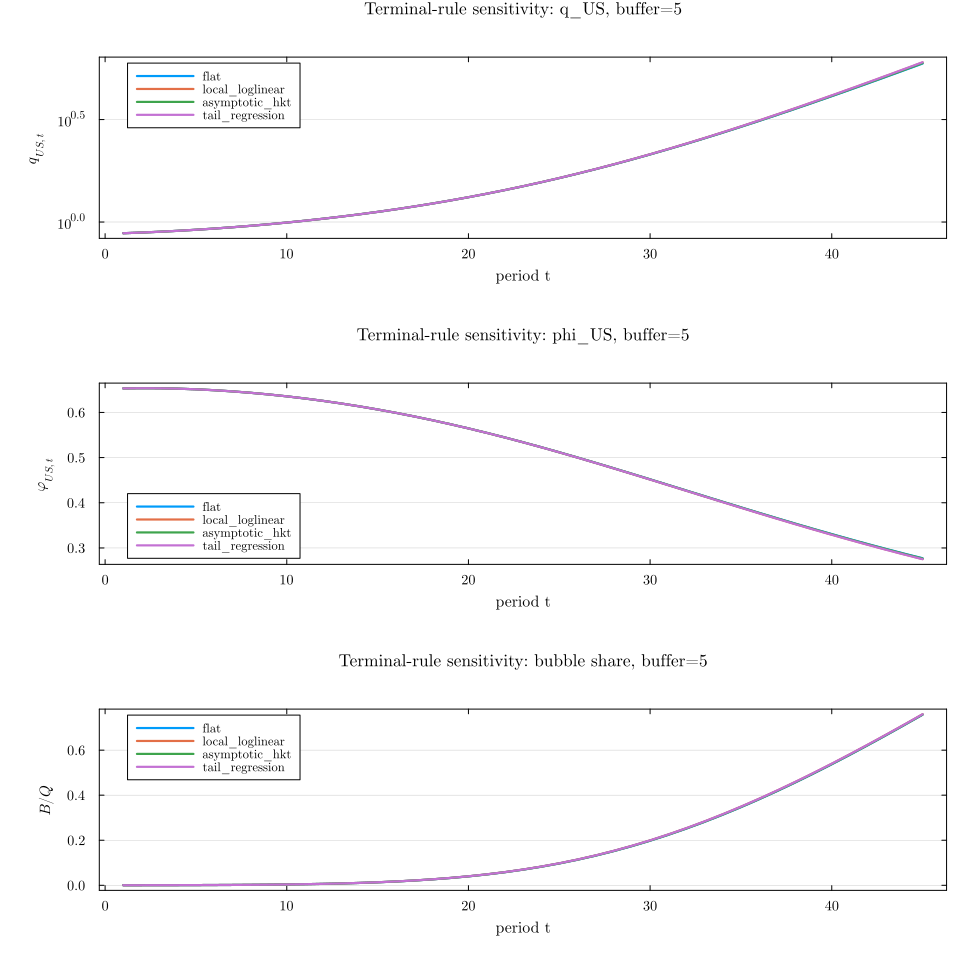

In [13]:
plot_buffer = BASELINE_SPEC.n_buffer in TERMINAL_BUFFER_GRID ? BASELINE_SPEC.n_buffer : first(TERMINAL_BUFFER_GRID)
plot_cases = [(rule, run_tail_case(TERMINAL_T_REPORT, plot_buffer, rule)) for rule in TERMINAL_RULES]
plot_cases = filter(rc -> rc[2].status == :ok, plot_cases)

p_q = plot(title="Terminal-rule sensitivity: q_US, buffer=$plot_buffer",
           xlabel="period t", ylabel=L"q_{US,t}", yscale=:log10, legend=:topleft)
p_phi = plot(title="Terminal-rule sensitivity: phi_US, buffer=$plot_buffer",
             xlabel="period t", ylabel=L"\varphi_{US,t}", legend=:bottomleft)
p_b = plot(title="Terminal-rule sensitivity: bubble share, buffer=$plot_buffer",
           xlabel="period t", ylabel=L"B/Q", legend=:topleft)

for (rule, c) in plot_cases
    tt = 1:length(c.result.u_path)
    plot!(p_q, tt, positive_for_log(path_vector(c.result, :q_US)), lw=2.2, label=String(rule))
    plot!(p_phi, tt, path_vector(c.result, :φ_US), lw=2.2, label=String(rule))
    plot!(p_b, tt, c.fv.bubble_share, lw=2.2, label=String(rule))
end

fig_terminal = plot(p_q, p_phi, p_b, layout=(3,1), size=(980, 980), bottom_margin=8mm)
savefig(fig_terminal, joinpath(OUTDIR, "terminal_rule_sensitivity_paths.png"))
fig_terminal

## 5. Reading the Evidence

For the horizon/buffer experiment, small `q` and `phi` errors through `T0 = 20, 30, 40` relative to the `12_v9` baseline indicate that the direct solved equilibrium path is stable. The separate B/Q path diagnostics should be read as a tail-valuation check: large B/Q movement with tiny `q` and `phi` movement points to sensitivity in the backward fundamental-value recursion rather than a different equilibrium path.

For the terminal-rule experiment, the robust pattern to look for is:

- `local_loglinear`, `asymptotic_hkt`, and `tail_regression` remain close over pre-terminal windows.
- `flat` is the outlier, especially as `T0` approaches the terminal date or when `n_buffer = 0`.
- Adding a buffer should push any closure sensitivity away from the economically reported part of the path.

The CSVs and figures are written to `Two_country_production/outputs_v43/approximation_error_in_tails/`.